<a href="https://colab.research.google.com/github/math288/math288.github.io/blob/main/math02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ニュートン法の計算
ニュートン法とは、方程式の解を近似的に求めることができるものである。  
x = c でf(x) = 0となるとする。  
初期値aを適当にとり、(a, f(a))が関数のグラフ上の点とする。  
さらにf(a) > 0 とし、fが下に凸な関数とする。
これらの条件のもとでニュートン法を適用すると、近似的な解を求めることができる。  
ニュートン法は更新式を用いて、次に次にと、求めるべきcの値へと近づけていく流れである。  
更新式は
$$a_{n + 1} = a_n - \frac{f(a_n)}{f'(a_n)}$$
これからグラフで可視化しながら何をしているか見てみる。

In [7]:
import sympy #sympyで、必要に応じて数値を正確な分数として表すことが可能になる

def f(x):
  #計算対象の関数
  return x**2 - 2

def f_prime(x):
    #導関数
    return 2 * x
#初期値
a0 = 2

#ニュートン法を1ステップ分計算
a1 = a0 - f(a0)/ f_prime(a0)

print(a1)


1.5


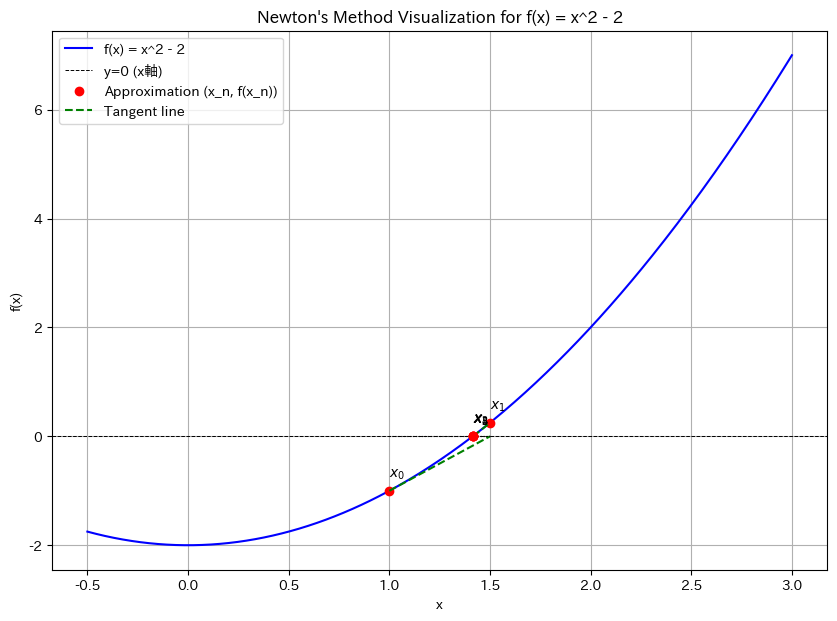

ニュートン法による近似値の履歴:
x_0: 1.000000
x_1: 1.500000
x_2: 1.416667
x_3: 1.414216
x_4: 1.414214
x_5: 1.414214


In [25]:
from tempfile import SpooledTemporaryFile
import matplotlib.pyplot as plt
import numpy as np
!pip install japanize-matplotlib
import japanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False #マイナス記号のエラー防止

#ニュートン法の関数定義
def newton_method_iterations(f, f_prime, x0, num_iterations= 5):
  x_values = [x0]
  for _ in range(num_iterations):
    if f_prime(x_values[-1]) == 0: #-1で末尾から1番目のものを選択している
       break #微分した時が0になった時は更新式で計算できない状態になるため破棄する
    x_next = x_values[-1] - f(x_values[-1]) / f_prime(x_values[-1])
    #ここでの-1という値は、今までで判明している最終的な更新式の値あるいは初期値である
    x_values.append(x_next)
  return x_values

def f(x):
    return x ** 2 - 2
def f_prime(x):
    return 2 * x
x0 = 1.0

#ニュートン法の反復計算
x_approximations = newton_method_iterations(f, f_prime, x0, num_iterations=5)
#プロット用のx範囲
x_plot = np.linspace(-0.5, 3.0, 400) # -0.5~3の範囲でx軸を表示
y_plot = f(x_plot)

plt.figure(figsize=(10, 7)) #横、縦の順での表示するグラフの表示の大きさ（インチ）
#関数を青で表示し、x軸の名前、色、太さ、線の種類を示す
plt.plot(x_plot, y_plot, label = 'f(x) = x^2 - 2', color= 'blue')
plt.axhline(0, color = 'black', linestyle = '--', linewidth = 0.7, label = 'y=0 (x軸)')

#各反復での点と接線を描画
for i, x_approx in enumerate(x_approximations):#enumerateを使い、値とi番目かも取得
    if i == 0:
       point_label = 'Approximation (x_n, f(x_n))' #同じ近似値の点には同じラベルをつける
    else:
       point_label = None

    plt.plot(x_approx, f(x_approx), 'o', color='red', markersize=6, label=point_label)


    plt.annotate(f'$x_{{{i}}}$', (x_approx, f(x_approx)),
             textcoords="offset points", xytext=(0, 10), fontsize=10)

    if i < len(x_approximations) -1:
       slope = f_prime(x_approx) #接線の傾き
       intercept = f(x_approx) -slope * x_approx #接線のy切片(直線の公式の変形から)
       tangent_x = np.linspace(min(x_approx, x_approximations[i + 1]),
                          max(x_approx, x_approximations[i + 1]), 100)
       tangent_y = slope * tangent_x + intercept
       tangent_label = 'Tangent line' if i == 0 else None
       plt.plot(tangent_x, tangent_y, '--', color ='green', linewidth = 1.5,
           label = tangent_label)
       plt.plot([x_approx, x_approximations[i + 1]], [0, 0], 'k:', linewidth=0.8)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("Newton's Method Visualization for f(x) = x^2 - 2")
plt.grid(True)
plt.legend()
plt.show()

print("ニュートン法による近似値の履歴:")
for i, x_val in enumerate(x_approximations):
    print(f"x_{i}: {x_val:.6f}")
